# Source of heterogeneity: quenched or emergent?

Own-degree erases the degree channel (σ ⊥ k, and a regular graph still multiscales), so the firm-to-firm
spread is **not** topological. What's left is the frozen coupling disorder {α_ij} and the chaotic dynamics
it drives. Which one *decides* a firm's size and volatility?

**Test.** Fix the graph **and** the couplings; vary **only** the initial condition w₀ (the `seed` in
`integrate` sets w₀, nothing else). For each firm $i$, compare its mean size $\bar S_i$ and volatility
$\sigma_i$ across ICs:

- **quenched** — the couplings decide → the *same* firms are big/volatile every run → high rank
  correlation across ICs;
- **emergent** — the chaos + IC decide → firm roles reshuffle → correlation near zero.

Baseline: correlating across runs with **different couplings** (firm $i$ is then a different firm) →
should give ≈0, anchoring the emergent end. Also: survivor **overlap** (Jaccard) across ICs — is even
*who survives* quenched?

In [1]:
import os, sys, time
while not os.path.isdir("relative_glv") and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")                                          # run from repo root OR notebooks/
sys.path.insert(0, os.getcwd())
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from relative_glv.model import coupling, integrate

SMOKE = os.environ.get("QN_SMOKE", "0") == "1"
MU, SIGMA, LAM = 1.76, 1.75, 1e-3
N, C = (1000, 100) if SMOKE else (4000, 100)
N_IC = 3 if SMOKE else 6                              # initial conditions per coupling realization
N_COUP = 2 if SMOKE else 3                            # coupling realizations
TMAX, N_EVAL = (100.0, 400) if SMOKE else (250.0, 700)
LATE, DT = ((75.0, 98.0) if SMOKE else (180.0, 240.0)), 0.5
print(f"{'SMOKE ' if SMOKE else ''}quench test  N={N}  {N_COUP} couplings x {N_IC} ICs each  window={LATE}")

def per_firm(alpha, ic_seed):
    """Per-firm mean size and MAD-volatility for ALL firms (aligned by index), + survival mask."""
    r = integrate(alpha, tmax=TMAX, n_eval=N_EVAL, lam=LAM, seed=ic_seed,
                  method="RK45", rtol=1e-4, atol=1e-7)
    if not r["success"]:
        return None
    t, W = r["t"], r["W"]; S = N * W
    win = (t >= LATE[0]) & (t <= LATE[1])
    tg = np.arange(LATE[0], LATE[1] + 1e-9, DT)
    lnS = np.array([np.interp(tg, t, np.log(np.maximum(S[i], 1e-12))) for i in range(S.shape[0])])
    g = np.diff(lnS, axis=1)
    Sbar = np.exp(lnS).mean(1)
    sig = np.sqrt(np.pi / 2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)
    return dict(Sbar=Sbar, sig=sig, surv=W[:, win].min(1) > 1e-6)  # share floor, as size_volatility

quench test  N=4000  3 couplings x 6 ICs each  window=(180.0, 240.0)


In [2]:
t0 = time.time()
# same-coupling / different-IC, per coupling realization
COUP = {}
for cs in range(N_COUP):
    alpha = coupling(N, MU, SIGMA, kind="powerlaw_owndeg", seed=cs)   # fixed graph+couplings
    runs = Parallel(n_jobs=6, backend="loky")(delayed(per_firm)(alpha, 1000 + ic) for ic in range(N_IC))
    COUP[cs] = [x for x in runs if x is not None]
print(f"integrated in {(time.time()-t0)/60:.1f} min")

def pair_stats(runs):
    """Pairwise (over ICs) Spearman of Sbar and sigma on shared survivors, + survivor Jaccard."""
    rS, rG, jac, ncom = [], [], [], []
    for a in range(len(runs)):
        for b in range(a + 1, len(runs)):
            both = runs[a]["surv"] & runs[b]["surv"]; uni = runs[a]["surv"] | runs[b]["surv"]
            ncom.append(int(both.sum()))
            jac.append(both.sum() / max(1, uni.sum()))
            if both.sum() >= 30:
                rS.append(spearmanr(runs[a]["Sbar"][both], runs[b]["Sbar"][both]).correlation)
                rG.append(spearmanr(runs[a]["sig"][both], runs[b]["sig"][both]).correlation)
    return np.array(rS), np.array(rG), np.array(jac), np.array(ncom)

allS, allG, allJ = [], [], []
print(f"\n{'coupling':<10}{'rho(Sbar)':>11}{'rho(sigma)':>12}{'survivor Jaccard':>18}{'shared firms':>14}")
for cs in range(N_COUP):
    rS, rG, jac, ncom = pair_stats(COUP[cs])
    allS.append(rS); allG.append(rG); allJ.append(jac)
    print(f"coupling {cs:<2}{np.mean(rS):>11.3f}{np.mean(rG):>12.3f}{np.mean(jac):>18.2f}{int(np.mean(ncom)):>14}")
rhoS = float(np.mean(np.concatenate(allS))); rhoG = float(np.mean(np.concatenate(allG)))
jacc = float(np.mean(np.concatenate(allJ)))

# baseline: DIFFERENT couplings (firm i is a different firm) -> expect ~0
b = COUP[0][0]["surv"] & COUP[1][0]["surv"]
rho_diff = float(spearmanr(COUP[0][0]["Sbar"][b], COUP[1][0]["Sbar"][b]).correlation)
print(f"\nSAME coupling, diff IC:  rho(Sbar)={rhoS:.3f}   rho(sigma)={rhoG:.3f}   survivor Jaccard={jacc:.2f}")
print(f"DIFF coupling (baseline): rho(Sbar)={rho_diff:.3f}   (≈0 expected)")
print(f"\n=> {'QUENCHED' if rhoS > 0.6 else 'EMERGENT' if rhoS < 0.25 else 'PARTIAL'}: "
      f"size is {'set by the couplings' if rhoS>0.6 else 'reshuffled by the dynamics' if rhoS<0.25 else 'partly both'}")

integrated in 0.5 min

coupling    rho(Sbar)  rho(sigma)  survivor Jaccard  shared firms
coupling 0       0.973       0.881              0.82           968
coupling 1       0.828       0.640              0.58           554
coupling 2       0.990       0.952              0.91           969

SAME coupling, diff IC:  rho(Sbar)=0.930   rho(sigma)=0.824   survivor Jaccard=0.77
DIFF coupling (baseline): rho(Sbar)=0.013   (≈0 expected)

=> QUENCHED: size is set by the couplings


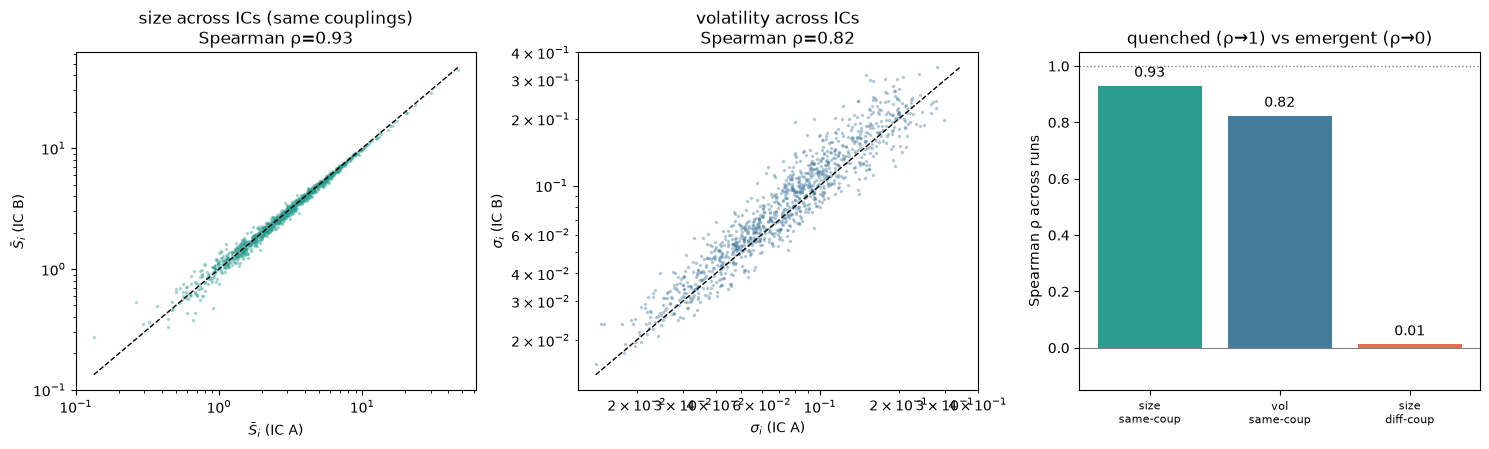

saved data/quench_test.npz and data/quench_test.png


In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6))
r0, r1 = COUP[0][0], COUP[0][1]                      # two ICs, same coupling
both = r0["surv"] & r1["surv"]

ax[0].loglog(r0["Sbar"][both], r1["Sbar"][both], ".", ms=3, alpha=0.3, color="#2a9d8f")
lim = [min(r0["Sbar"][both].min(), r1["Sbar"][both].min()), max(r0["Sbar"][both].max(), r1["Sbar"][both].max())]
ax[0].plot(lim, lim, "k--", lw=1)
ax[0].set(xlabel=r"$\bar S_i$ (IC A)", ylabel=r"$\bar S_i$ (IC B)",
          title=f"size across ICs (same couplings)\nSpearman ρ={rhoS:.2f}")

ax[1].loglog(r0["sig"][both], r1["sig"][both], ".", ms=3, alpha=0.3, color="#457b9d")
lim = [min(r0["sig"][both].min(), r1["sig"][both].min()), max(r0["sig"][both].max(), r1["sig"][both].max())]
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set(xlabel=r"$\sigma_i$ (IC A)", ylabel=r"$\sigma_i$ (IC B)",
          title=f"volatility across ICs\nSpearman ρ={rhoG:.2f}")

ax[2].bar([0, 1, 2], [rhoS, rhoG, rho_diff], color=["#2a9d8f", "#457b9d", "#e76f51"])
ax[2].axhline(1, color="grey", ls=":", lw=1); ax[2].axhline(0, color="grey", lw=0.8)
ax[2].set(xticks=[0, 1, 2], ylabel="Spearman ρ across runs", ylim=(-0.15, 1.05),
          title="quenched (ρ→1) vs emergent (ρ→0)")
ax[2].set_xticklabels(["size\nsame-coup", "vol\nsame-coup", "size\ndiff-coup"], fontsize=8)
for i, v in enumerate([rhoS, rhoG, rho_diff]):
    ax[2].text(i, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout(); plt.savefig("data/quench_test.png", dpi=120); plt.show()
np.savez("data/quench_test.npz", rhoS=rhoS, rhoG=rhoG, rho_diff=rho_diff, jaccard=jacc,
         N=N, N_IC=N_IC, N_COUP=N_COUP)
print("saved data/quench_test.npz and data/quench_test.png")

## Reading

- **ρ(size) → 1** (points hug the diagonal): a firm's size is **quenched** — the couplings decide who's
  big, independent of initial conditions. The heterogeneity is frozen in the disorder.
- **ρ(size) → 0** (scatter cloud, like the diff-coupling baseline): size is **emergent** — the chaos +
  IC decide, and firm roles reshuffle every run. The disorder sets the *rules*, the dynamics pick the
  *winners*.
- **ρ(volatility)** vs **ρ(size)**: they can differ — e.g. size quenched but volatility partly emergent.
- **survivor Jaccard**: is even *who survives* quenched (same firms every run) or a dynamical lottery?

Whichever way it lands names the source of the heterogeneity that the DMFT order parameters miss.